In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fusicfenta/cat-and-dog")

print("Path to dataset files:", path)

100%|██████████| 218M/218M [00:13<00:00, 17.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1


In [2]:
cd /root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1


In [3]:
ls

dataset/


In [4]:
cd dataset

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset


In [5]:
ls

single_prediction/  test_set/  training_set/


In [6]:
cd training_set/

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset/training_set


In [7]:
ls

cats/  dogs/


In [8]:
cd ..

/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset


In [9]:
import tensorflow as tf
import os

In [10]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [16]:
train_dir = "/root/.cache/kagglehub/datasets/fusicfenta/cat-and-dog/versions/1/dataset/training_set"

In [17]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(256,256),
    batch_size=32
)

Found 8000 files belonging to 2 classes.


In [18]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(256,256),
    batch_size=32
)


Found 8000 files belonging to 2 classes.


In [19]:
training_set.class_names

['cats', 'dogs']

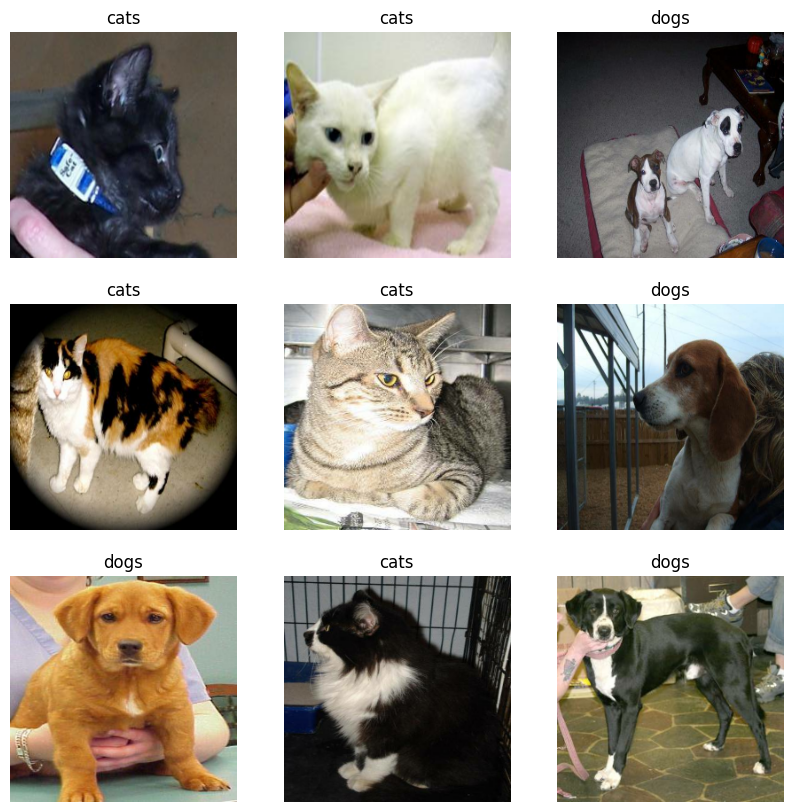

In [20]:
import matplotlib.pyplot as plt

for images, labels in training_set.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(training_set.class_names[labels[i]])
        plt.axis("off")

In [21]:
data_iterator = training_set.as_numpy_iterator()

In [23]:
batch = data_iterator.next()


In [24]:
len(batch)

2

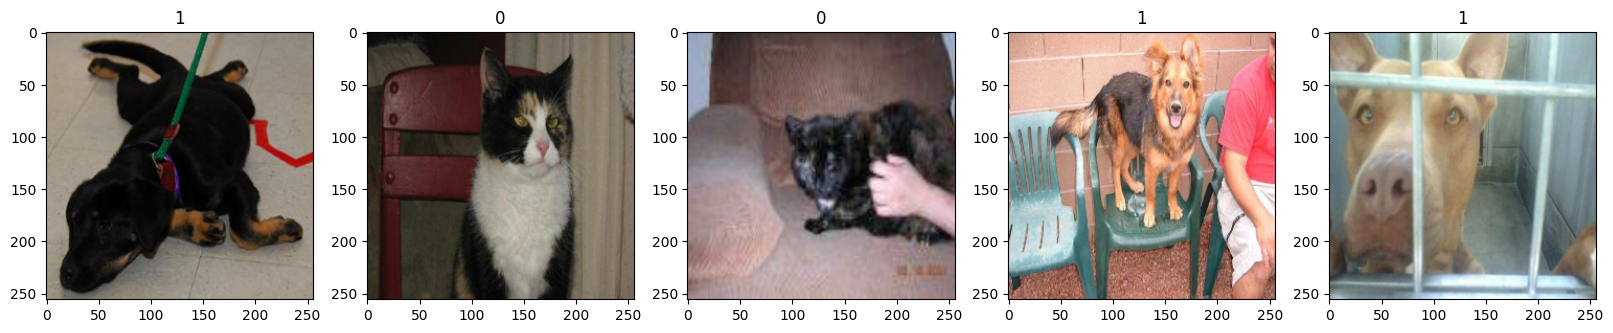

In [25]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [27]:
data = training_set.map(lambda x,y: (x/255, y))
#newrel network perform well data into 0 to 1 smaller the data faster the perfomace
data.as_numpy_iterator().next()

(array([[[[0.20304574, 0.22557178, 0.14738785],
          [0.11336519, 0.12035315, 0.05280566],
          [0.12655637, 0.11245269, 0.07235718],
          ...,
          [0.3354154 , 0.27718163, 0.24274057],
          [0.60609645, 0.5569313 , 0.5443241 ],
          [0.3843746 , 0.30830094, 0.31522074]],
 
         [[0.11873603, 0.15792273, 0.09343632],
          [0.09622259, 0.1241791 , 0.05365213],
          [0.10980664, 0.11108474, 0.07208151],
          ...,
          [0.26877034, 0.21746159, 0.17825356],
          [0.62680185, 0.5956518 , 0.5696597 ],
          [0.3855602 , 0.33859462, 0.32965752]],
 
         [[0.03351728, 0.10504761, 0.02077883],
          [0.12438224, 0.16879295, 0.10413302],
          [0.10741334, 0.1144378 , 0.08166096],
          ...,
          [0.3822015 , 0.33808383, 0.2857401 ],
          [0.57519066, 0.56979847, 0.52354485],
          [0.38875848, 0.37872478, 0.33966228]],
 
         ...,
 
         [[0.6251329 , 0.7590807 , 0.58542037],
          [0.42557

In [28]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% test
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [29]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
model = Sequential()


In [30]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])


In [32]:
 model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.5259 - loss: 0.6945 - val_accuracy: 0.6125 - val_loss: 0.6769
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.6230 - loss: 0.6466 - val_accuracy: 0.6800 - val_loss: 0.6166
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.7223 - loss: 0.5475 - val_accuracy: 0.6706 - val_loss: 0.5970
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.7729 - loss: 0.4769 - val_accuracy: 0.7300 - val_loss: 0.5421
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.8439 - loss: 0.3459 - val_accuracy: 0.7450 - val_loss: 0.5820
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.9016 - loss: 0.2356 - val_accuracy: 0.7456 - val_loss: 0.6565
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.9514 - loss: 0.1342 - val_accuracy: 0.7269 - val_loss: 0.7263
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.9673 - loss: 0.0909 -

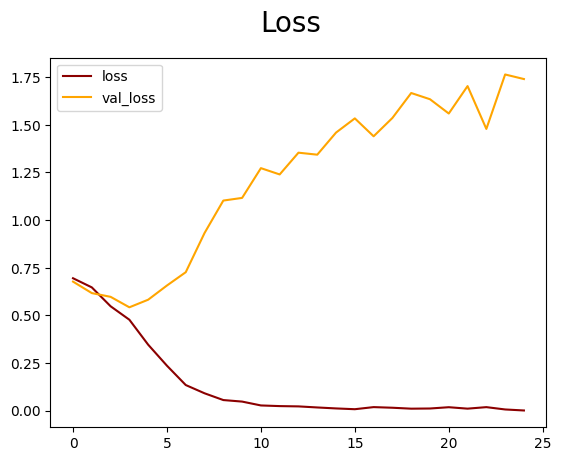

In [34]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

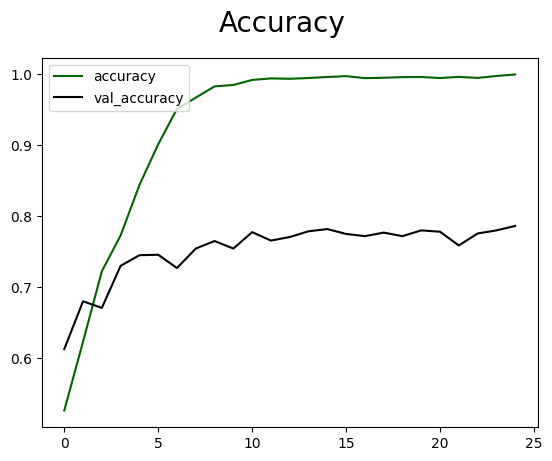

In [35]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()


In [36]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
Pre = Precision()
Re = Recall()
Acc = BinaryAccuracy()
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    Pre.update_state(y, yhat)
    Re.update_state(y, yhat)
    Acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [37]:
Pre.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.7185184955596924>

In [38]:

print(Re.result())


tf.Tensor(0.74807197, shape=(), dtype=float32)


In [39]:
print(Acc.result())

tf.Tensor(0.735, shape=(), dtype=float32)


In [41]:
import cv2

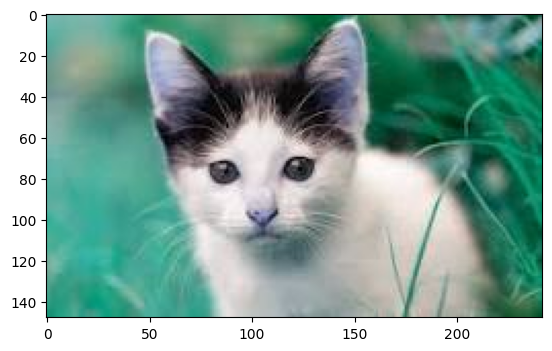

In [47]:
img = cv2.imread('/content/download.jfif')
plt.imshow(img)
plt.show()

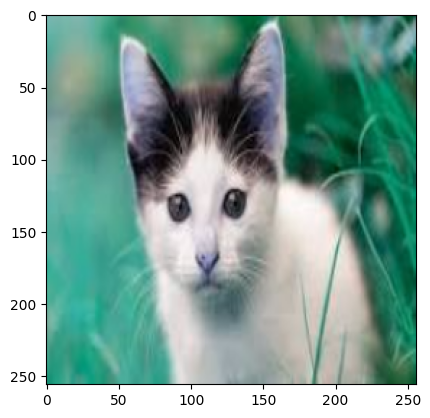

In [48]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [49]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


In [50]:
yhat

array([[1.4399151e-05]], dtype=float32)

In [51]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


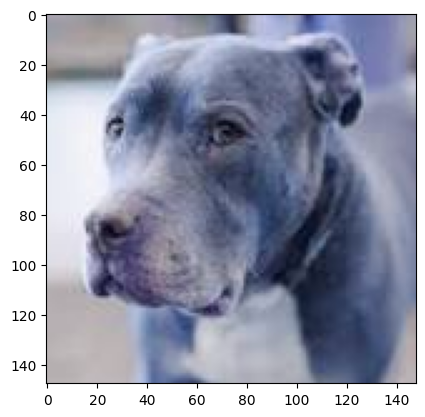

In [52]:
img = cv2.imread('/content/download (1).jfif')
plt.imshow(img)
plt.show()


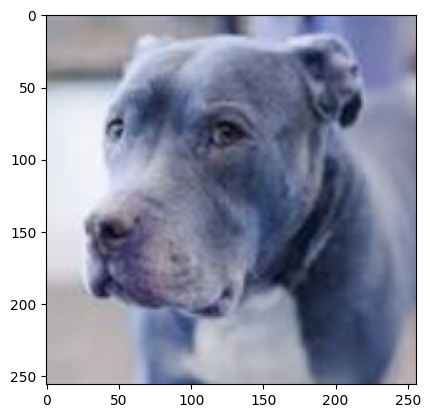

In [53]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [54]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [55]:
yhat

array([[0.9979418]], dtype=float32)

In [57]:
if yhat > 0.5:
    print(f'Predicted class is dog')
else:
    print(f'Predicted class is cat')

Predicted class is dog


In [59]:
model.save(os.path.join('models','image_classifier_models.h5'))

In [61]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

Pre = Precision()
Re = Recall()
Acc = BinaryAccuracy()

for batch in training_set.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)

    Pre.update_state(y, yhat)
    Re.update_state(y, yhat)
    Acc.update_state(y, yhat)

print("Precision:", Pre.result().numpy())
print("Recall:", Re.result().numpy())
print("Accuracy:", Acc.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━